In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
from scipy import stats

In [2]:
# import self created functions
from tukey import tukey
from graphical_comp_mean import graphical_comp_mean

In [3]:
alpha = '\N{GREEK SMALL LETTER ALPHA}'


### Problem 1

In [4]:
df_01 = pd.DataFrame({
    'treatment': np.repeat(np.arange(4)+1,4),
    'strength': [3129,3000,2865,2890,3200,3300,2975,3150,2800,2900,2985,3050,2600,2700,2600,2765]
})


a. statistical analysis
* null hypothesis ($H_0$): mixing techniques affect the strength of the cement
* alternative hypothesis ($H_1$): mixing techniques do not affect the strength of the cement
* $\alpha = 0.05$

In [5]:
df_01['t_ave'] = df_01.groupby('treatment')['strength'].transform('mean')
df_01['ave'] = df_01['strength'].mean()
df_01['t_dev'] = df_01['t_ave'] - df_01['ave']
df_01['residual'] = df_01['strength'] - df_01['t_ave']


In [6]:
# sum of squares of residuals with 16-4 degrees of freedom
SSE_01 = (df_01['residual']**2).sum()
# Mean square of residuals
MSE_01 = SSE_01/12
# sum of squares of treatment deviations with 4-1 degrees of freedom
SST_01 = (df_01['t_dev']**2).sum()
# mean square of treatment deviations
MST_01 = SST_01/3

# F statistic
F_01 = MST_01 / MSE_01
# p value
p_01 = stats.f.sf(F_01, dfn=3, dfd=12)
print(f'the p value for the test is {p_01.round(3)}, smaller than the pre selected {alpha}=0.05. the null hypothesis is safe to reject')

the p value for the test is 0.0, smaller than the pre selected α=0.05. the null hypothesis is safe to reject


b. graphical display of the data

conclusion: treatment 2 / 4 increase / decrease the tensile strength significantly

In [7]:
# generate data to plot the t statistic distribution
loc_01 = df_01['strength'].mean()
scale_01 = np.sqrt(MSE_01/4)
dof_01 = 12 # inherent from MSE_01
range_01 = 3 * scale_01

x_01 = np.linspace(-range_01,range_01,1001)+loc_01
y_01 = stats.t.pdf(x_01,loc=loc_01, scale=scale_01, df=dof_01)

[Text(2971.0, 0.0002, '1'),
 Text(3156.25, 0.0002, '2'),
 Text(2933.75, 0.0002, '3'),
 Text(2666.25, 0.0002, '4')]

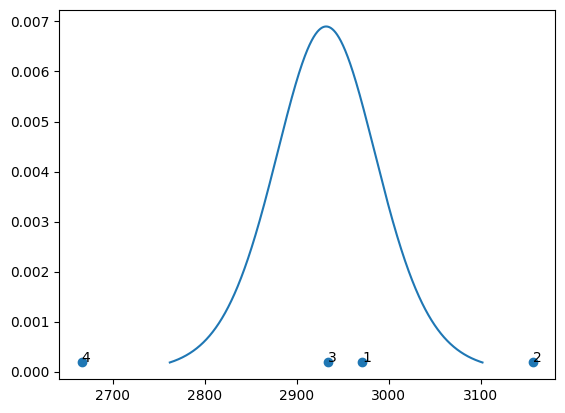

In [8]:
plt.plot(x_01, y_01)
plt.scatter(df_01.groupby('treatment')['strength'].mean().values, [0.0002]*4)
[plt.text(x,y,s) for x,y,s in zip(df_01.groupby('treatment')['strength'].mean().values, [0.0002]*4, df_01.groupby('treatment')['strength'].mean().index)]

c. The Fisher Least Significant Difference (LSD) Method
$$LSD = t_{\alpha/2, N-a}  \sqrt{MS_E(\frac{1}{n_i} + \frac{1}{n_i})}$$

In [9]:
LSD_01 = stats.t.sf(0.025,df=12) * np.sqrt(MSE_01*(1/4+1/4))
LSD_01

np.float64(39.25796852380329)

In [10]:
df_01.groupby('treatment')['strength'].mean()[[1,2]].diff()

treatment
1       NaN
2    185.25
Name: strength, dtype: float64

In [11]:
diff_comb_01 = []
from itertools import combinations
diff_comb_01.extend(combinations([1,2,3,4],2))

diff_comb_01

[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

 The least significant difference is 39.258.
The difference between treatment 1 and 2 is 185.25.

 The least significant difference is 39.258.
The difference between treatment 1 and 3 is 37.25.

 The least significant difference is 39.258.
The difference between treatment 1 and 4 is 304.75.

 The least significant difference is 39.258.
The difference between treatment 2 and 3 is 222.5.

 The least significant difference is 39.258.
The difference between treatment 2 and 4 is 490.0.

 The least significant difference is 39.258.
The difference between treatment 3 and 4 is 267.5.



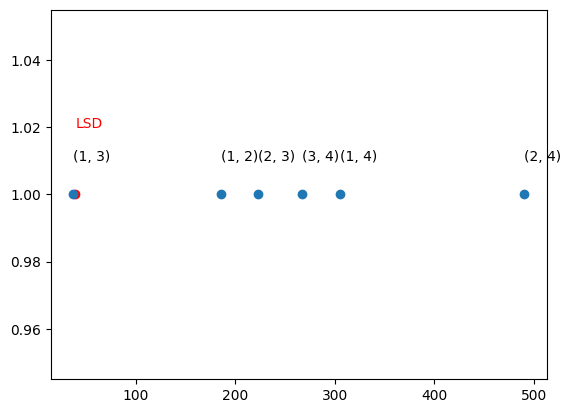

In [12]:
for i in diff_comb_01:
    print(f''' The least significant difference is {LSD_01.round(3)}.
The difference between treatment {i[0]} and {i[1]} is {np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff()).values[1].round(3)}.
''')
    
plt.scatter([LSD_01], [1], c='r')
plt.text(LSD_01, 1.02, 'LSD', c='r')
plt.scatter([np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]) for i in diff_comb_01] ,[1]*len(diff_comb_01))
for i in diff_comb_01:
    plt.text(np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]), 1.01, i)

d. Normality plot of the residuals

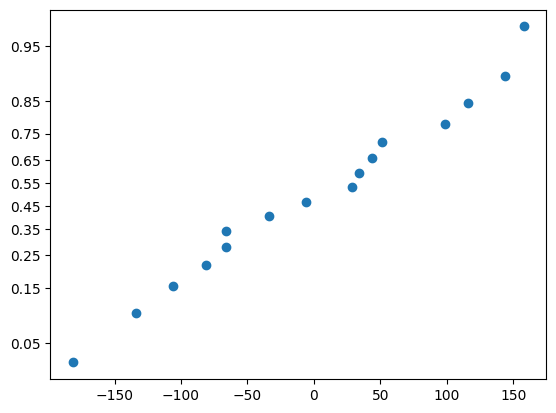

In [13]:
plt.scatter(df_01.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,17)[:-1]+1/32))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))
plt.show() # no violation of normality

e. Residuals agains predicted tensile strength (the treatment means)

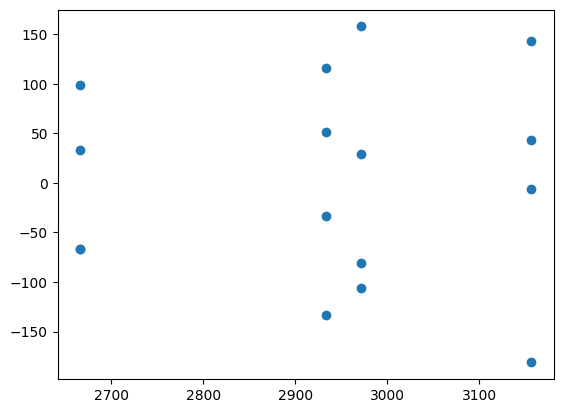

In [14]:
# plot residuals against treatment means
# The residuals are independent of the predicted tensile strengths
plt.scatter(df_01['ave'] + df_01['t_dev'], df_01['residual'])

f. Prepare a scatter plot of the results to aid the interpretation of the results of this experiment

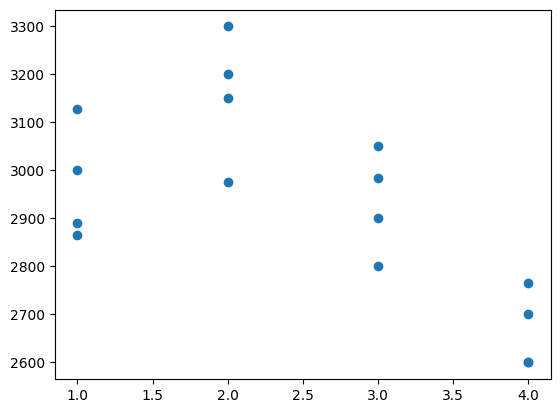

In [15]:
plt.scatter(df_01.treatment, df_01.strength)

# Problem 2
a. Duncan's multiple range test gives the same results as the Fisher Least Significance Method
* $\alpha = 0.05$
* the standard error of each treatment averages is 
$$S_t = \sqrt{\frac{MS_E}{n}}$$

In [16]:
# standard error of each treatment average
S_t_02 = np.sqrt(MSE_01/4)
r_2_02 = 3.08
r_3_02 = 3.23
r_4_02 = 3.33

In [17]:
R_2_02 = r_2_02 * S_t_02
R_3_02 = r_3_02 * S_t_02
R_4_02 = r_4_02 * S_t_02

The least significant ranges are 174.406, 182.9, and 188.562

The difference between treatment 1 and 2 is 185.25.


The difference between treatment 1 and 3 is 37.25.


The difference between treatment 1 and 4 is 304.75.


The difference between treatment 2 and 3 is 222.5.


The difference between treatment 2 and 4 is 490.0.


The difference between treatment 3 and 4 is 267.5.



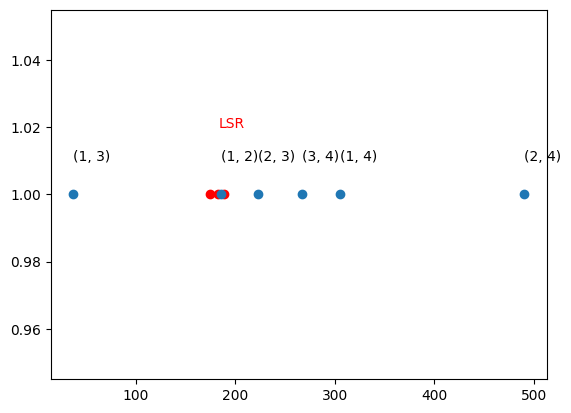

In [18]:
print(f'The least significant ranges are {R_2_02.round(3)}, {R_3_02.round(3)}, and {R_4_02.round(3)}')
for i in diff_comb_01:
    print(f'''
The difference between treatment {i[0]} and {i[1]} is {np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff()).values[1].round(3)}.
''')
    
plt.scatter([R_2_02, R_3_02, R_4_02], [1,1,1], c='r')
plt.text(R_3_02, 1.02, 'LSR', c='r')
plt.scatter([np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]) for i in diff_comb_01] ,[1]*len(diff_comb_01))
for i in diff_comb_01:
    plt.text(np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]), 1.01, i)

b. Tukey's test
* $\alpha = 0.05$ 
* the studentized range statistic
$$q = \frac{\bar{y}_{max} - \bar{y}_{min}}{\sqrt{MS_E/n}}$$
* For equal sample size
$$T_\alpha = q_\alpha(a,f) \sqrt{\frac{MS_E}{n}}$$
* For non-equal sample size
$$T_\alpha = \frac{q_\alpha(a,f)}{\sqrt{2}} \sqrt{MS_E(\frac{1}{n_i}+\frac{1}{n_j})}$$
* the $1-\alpha$ confidence interval,
$$\bar{y}_{i.} - \bar{y}_{j.} - T_\alpha \le \mu_i - \mu_j \le \bar{y}_{i.} - \bar{y}_{j.} + T_\alpha, i\ne j$$
* in this case, $\alpha=0.05$, degree of freedom $f=16-4=12$, and sample size is euqal $n=4$. the final result is different from Duncan's test and Fisher's test.

In [19]:
q_02 = 4.20
T_02 = q_02 * np.sqrt(MSE_01/4)

The Tukey's least significant difference is 237.826

The difference between treatment 1 and 2 is 185.25.


The difference between treatment 1 and 3 is 37.25.


The difference between treatment 1 and 4 is 304.75.


The difference between treatment 2 and 3 is 222.5.


The difference between treatment 2 and 4 is 490.0.


The difference between treatment 3 and 4 is 267.5.



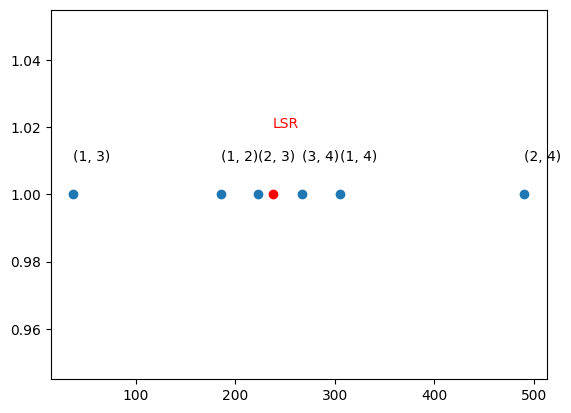

In [20]:
print(f'The Tukey\'s least significant difference is {T_02.round(3)}')
for i in diff_comb_01:
    print(f'''
The difference between treatment {i[0]} and {i[1]} is {np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff()).values[1].round(3)}.
''')
    
plt.scatter([T_02], [1], c='r')
plt.text(T_02, 1.02, 'LSR', c='r')
plt.scatter([np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]) for i in diff_comb_01] ,[1]*len(diff_comb_01))
for i in diff_comb_01:
    plt.text(np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]), 1.01, i)

In [21]:
print(stats.tukey_hsd(*(df_01.groupby('treatment')['strength'].apply(list).values)))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)   -185.250     0.149  -423.000    52.500
 (0 - 2)     37.250     0.965  -200.500   275.000
 (0 - 3)    304.750     0.012    67.000   542.500
 (1 - 0)    185.250     0.149   -52.500   423.000
 (1 - 2)    222.500     0.069   -15.250   460.250
 (1 - 3)    490.000     0.000   252.250   727.750
 (2 - 0)    -37.250     0.965  -275.000   200.500
 (2 - 1)   -222.500     0.069  -460.250    15.250
 (2 - 3)    267.500     0.026    29.750   505.250
 (3 - 0)   -304.750     0.012  -542.500   -67.000
 (3 - 1)   -490.000     0.000  -727.750  -252.250
 (3 - 2)   -267.500     0.026  -505.250   -29.750



c. This is because Fisher least significant difference method and Duncan's method are more powerful in detecting true difference in means.

In [22]:
df_01.groupby('treatment')['strength'].apply(list).values

array([list([3129, 3000, 2865, 2890]), list([3200, 3300, 2975, 3150]),
       list([2800, 2900, 2985, 3050]), list([2600, 2700, 2600, 2765])],
      dtype=object)

### Problem 3

In [23]:
# 95% confidence interval on the mean tensile strength using t statistic with a degree of freedom of (16-4)=12. Two tailed test
t_03 = stats.t.isf(0.025, scale=np.sqrt(MSE_01/4), df=12)

In [24]:
for i in range(4):
    print(f'The 95% confidence interval on the mean of treatment {i+1} is from {(df_01.groupby('treatment')['strength'].mean().values[i] - t_03).round(2)} to {(df_01.groupby('treatment')['strength'].mean().values[i] + t_03).round(2)}')

The 95% confidence interval on the mean of treatment 1 is from 2847.62 to 3094.38
The 95% confidence interval on the mean of treatment 2 is from 3032.87 to 3279.63
The 95% confidence interval on the mean of treatment 3 is from 2810.37 to 3057.13
The 95% confidence interval on the mean of treatment 4 is from 2542.87 to 2789.63


In [25]:
# find 95% confidence interval on the difference on means for treatment 1 and 3 using Tukey's test statistic
d13_03 = df_01.groupby('treatment')['strength'].mean()[[1,3]].diff(-1).values[0] #u1 - u3
d13_03

np.float64(37.25)

In [26]:
print(f'''
      The 95% confidence interval on the difference in means for treatment 1 and 3 is {(d13_03 - T_02).round(2)} to {(d13_03 + T_02).round(2)}.
      This range covers 0, meaning no significant difference btw 1 and 3 at a significant level of {alpha}=0.05
      ''')


      The 95% confidence interval on the difference in means for treatment 1 and 3 is -200.58 to 275.08.
      This range covers 0, meaning no significant difference btw 1 and 3 at a significant level of α=0.05
      


### Problem 4

In [27]:
df_04 = pd.DataFrame({
    'temp': [100]*5+[125]*4+[150]*5+[175]*4,
    'density': [21.8,21.9,21.7,21.6,21.7,21.7,21.4,21.5,21.4,21.9,21.8,21.8,21.6,21.5,21.9,21.7,21.8,21.4]
})

a. analysis of variance

In [28]:
df_04['ave'] = df_04['density'].mean()
df_04['t_ave'] = df_04.groupby('temp')['density'].transform('mean')
df_04['t_dev'] = df_04['t_ave'] - df_04['ave']
df_04['residual'] = df_04['density'] - df_04['t_ave']

In [29]:
SSE_04 = (df_04['residual']**2).sum() # sum of squares of residuals (within treatment deviations) with (18-4)=14 degrees of freedom
MSE_04 = SSE_04/14 # mean square, an estimate of standard deviation
SST_04 = (df_04['t_dev']**2).sum() # sum of squares of treatment deviations from grand average (btw treatment deviations) with (4-1)=3 degrees of freedom
MST_04 = SST_04/3 # mean square, an estimate of standard deviation btw treatments

# f statistic
f_04 = MST_04 / MSE_04

# p value of the test
p_04 = stats.f.sf(f_04, dfn=3, dfd=14)
print(f'The p value of the test is {p_04.round(3)}. There is no significant difference on the brick density from the temperature at the significance level of {alpha}=0.05')

The p value of the test is 0.157. There is no significant difference on the brick density from the temperature at the significance level of α=0.05


b. Yes it is. Duncan's multiple range test can be used for non-equal size samples.

c. check residuals
* The plot below shows there is no significant violation of normality assumption

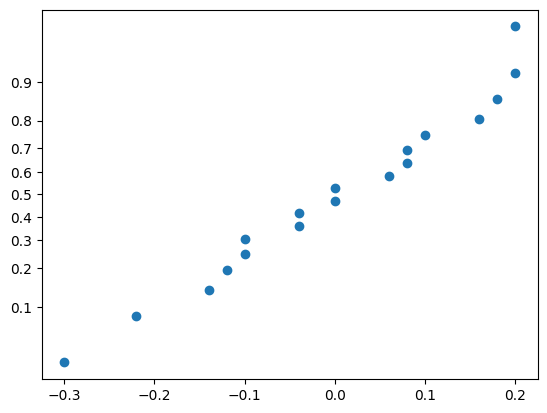

In [30]:
plt.scatter(df_04['residual'].sort_values(), -stats.norm.isf(np.linspace(0,1,19)[:-1]+1/36))
plt.yticks(-stats.norm.isf(np.linspace(0.1,0.9,9)), np.linspace(0.1,0.9,9).round(2))
plt.show()

d. the graphical display of the treatment means with the corresponding t distribution

The graphical display is consistent with the results of the analysis of variance in (a)

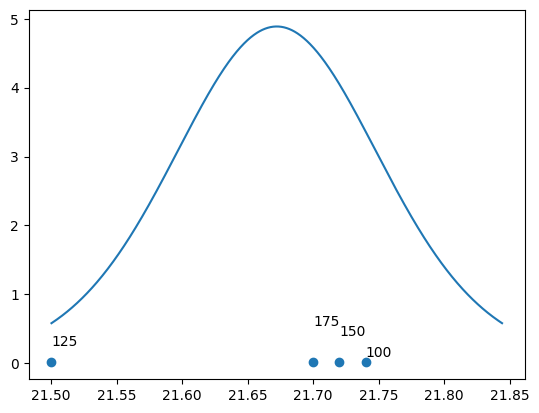

In [31]:
loc_04 = df_04['density'].mean() # the grand average
scale_04 = np.sqrt(MSE_04 / 4) # the standard error of the mean, used as the scale for the t test, the degree of freedom is 14, inherented from MSE_04
range_04 = stats.t.isf(0.025, scale=scale_04, df=14) # a mapping range corresponding to (1-0.05) or 95% confidence interval

x_04 = np.linspace(-range_04, range_04, 1001) # the mapping x
y_04 = stats.t.pdf(x_04, scale=scale_04, df=14) # the corresponding probability density for each x

plt.plot(x_04+loc_04, y_04)
plt.scatter(df_04.groupby('temp')['density'].mean(), [0.01]*4)
for i in range(4):
    plt.text(df_04.groupby('temp')['density'].mean().values[i], 0.1+0.15*i, df_04.groupby('temp')['density'].mean().index[i])
plt.show()

In [32]:
df_04.groupby('temp')['density'].mean()

temp
100    21.74
125    21.50
150    21.72
175    21.70
Name: density, dtype: float64

### Problem 5
The Fisher Least Significant Difference (LSD) Method for unequal sample sizes
$$LSD = t_{\alpha/2, N-a}  \sqrt{MS_E(\frac{1}{n_i} + \frac{1}{n_j})}, i\ne j$$

In [33]:
def fisher_lsd_05(n1, n2):
    return stats.t.isf(0.025,df=14)*np.sqrt(MSE_04*(1/n1+1/n2))

In [34]:
df_04.groupby('temp')['density'].mean()

temp
100    21.74
125    21.50
150    21.72
175    21.70
Name: density, dtype: float64

In [35]:
temp_04 = df_04.groupby('temp')['density'].mean().index.tolist() # all four temperatures (treatments)
temp_comb_04 = [] # create a list to store all temperature combinations (comparisons)
from itertools import combinations
temp_comb_04.extend(combinations(temp_04,2))
temp_comb_04

[(100, 125), (100, 150), (100, 175), (125, 150), (125, 175), (150, 175)]

In [36]:
for temp_comb in temp_comb_04:
    print(f'''
{temp_comb},
Absolute difference: {np.abs(df_04.groupby('temp')['density'].mean()[list(temp_comb)].diff().values[1]).round(3)},
Fisher least significant difference: {fisher_lsd_05((df_04['temp'] == temp_comb[0]).sum(),  (df_04['temp'] == temp_comb[1]).sum()).round(3)} 
''')


(100, 125),
Absolute difference: 0.24,
Fisher least significant difference: 0.231 


(100, 150),
Absolute difference: 0.02,
Fisher least significant difference: 0.218 


(100, 175),
Absolute difference: 0.04,
Fisher least significant difference: 0.231 


(125, 150),
Absolute difference: 0.22,
Fisher least significant difference: 0.231 


(125, 175),
Absolute difference: 0.2,
Fisher least significant difference: 0.243 


(150, 175),
Absolute difference: 0.02,
Fisher least significant difference: 0.231 



### Problem 6

In [37]:
df_06 = pd.DataFrame({
    'coating': np.repeat(np.arange(4)+1,4),
    'conductivity': [143,141,150,146,152,149,137,143,134,136,132,127,129,127,132,129]
})

a. analysis of variance to check if there is difference in conductivity due to coating type.
- null hypothesis ($H_0$): no difference, or btw treatment variance not larger than within treatment variance ($\sigma^2_T \le \sigma^2_{E}$)
- alternative hypothesis ($H_1$): significant difference, or btw treatment variance larger than within treatment variance ($\sigma^2_T > \sigma^2_{E}$)
- $\alpha=0.05$

In [38]:
df_06['ave'] = df_06['conductivity'].mean() # grand average
df_06['t_ave'] = df_06.groupby('coating')['conductivity'].transform('mean') # average of each coating type
df_06['residual'] = df_06['conductivity'] - df_06['t_ave'] # residual or within treatment deviations
df_06['t_dev'] = df_06['t_ave'] - df_06['ave'] # btw treatment deviations

SSE_06 = (df_06['residual']**2).sum() # sum of squares for residuals, 12 degrees of freedom
MSE_06 = SSE_06/12 # mean square for residuals, estimate of the test variance
SST_06 = (df_06['t_dev']**2).sum() # sum of squares for the btw treatment deviations, 3 degrees of freedom
MST_06 = SST_06/3 # mean square for treatment deviations, estimate of the treatment variance

f_06 = MST_06/MSE_06 # f statistic with 3 and 12 degrees of freedom
p_06 = stats.f.sf(f_06, dfn=3, dfd=12)

print(f'''
The p value for the test is {p_06.round(4)}, smaller than the pre-selected {alpha}=0.05. There is significant difference in conductivity due to coating type.      
''')


The p value for the test is 0.0003, smaller than the pre-selected α=0.05. There is significant difference in conductivity due to coating type.      



In [39]:
# b
print(f'The overall mean is {df_06['conductivity'].mean().round(1)}')
for i in range(4):
    print(f'The treatment effect of coating {i+1} is {df_06[df_06['coating']==i+1]['t_dev'].unique()[0]}')

The overall mean is 137.9
The treatment effect of coating 1 is 7.0625
The treatment effect of coating 2 is 7.3125
The treatment effect of coating 3 is -5.6875
The treatment effect of coating 4 is -8.6875


In [40]:
# c
# 95% confidence interval estimate of the mean of coating type 4
df_06[df_06['coating']==4]['t_ave'].unique()[0] # the mean of coating type 4
se_06c1 = np.sqrt(MSE_06/4) # the standard error of the mean of coating type 4, 12 degrees of freedom
t_06c1 = stats.t.isf(0.025,df=12) # t statistc, two tail test

print(f'The 95% confidence interval estimate of the mean of coating type 4 is from {(df_06[df_06['coating']==4]['t_ave'].unique()[0] - t_06c1*se_06c1).round(1)} to {(df_06[df_06['coating']==4]['t_ave'].unique()[0] + t_06c1*se_06c1).round(1)}')

The 95% confidence interval estimate of the mean of coating type 4 is from 124.4 to 134.1


In [41]:
# 99% confidence interval estimate of the mean difference btw coating type 1 and 4

d14_06 = df_06[df_06['coating']==1]['t_ave'].unique()[0] - df_06[df_06['coating']==4]['t_ave'].unique()[0] # the mean difference of coating type 1 vs 4
se_06c2 = np.sqrt(MSE_06/4 + MSE_06/4) # the standard error of the mean difference, 12 degrees of freedom
t_06c2 = stats.t.isf(0.005,df=12) # t statistc, two tail test

print(f'The 99% confidence interval estimate of the mean difference btw coating type 1 vs 4 is from {(d14_06 - t_06c2*se_06c2).round(1)} to {(d14_06 + t_06c2*se_06c2).round(1)}')

The 99% confidence interval estimate of the mean difference btw coating type 1 vs 4 is from 6.2 to 25.3


In [42]:
def fisher_lsd_06(n1, n2):
    return stats.t.isf(0.025,df=12)*np.sqrt(MSE_06*(1/n1+1/n2))

In [43]:
# d
coatings_06 = [1,2,3,4] # all four treatments
coating_comb_06 = [] # create a list to store all pairs
from itertools import combinations
coating_comb_06.extend(combinations(coatings_06,2))

for coating_comb in coating_comb_06:
    print(f'''
{coating_comb},
Absolute difference: {np.abs(df_06.groupby('coating')['conductivity'].mean()[list(coating_comb)].diff().values[1]).round(3)},
Fisher least significant difference: {fisher_lsd_06((df_06['coating'] == coating_comb[0]).sum(),  (df_06['coating'] == coating_comb[1]).sum()).round(3)} 
''')


(1, 2),
Absolute difference: 0.25,
Fisher least significant difference: 6.836 


(1, 3),
Absolute difference: 12.75,
Fisher least significant difference: 6.836 


(1, 4),
Absolute difference: 15.75,
Fisher least significant difference: 6.836 


(2, 3),
Absolute difference: 13.0,
Fisher least significant difference: 6.836 


(2, 4),
Absolute difference: 16.0,
Fisher least significant difference: 6.836 


(3, 4),
Absolute difference: 3.0,
Fisher least significant difference: 6.836 



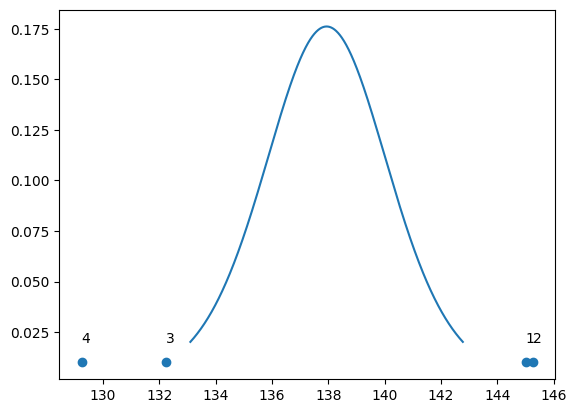

In [44]:
# e coating 2 has the highest conductivity
# generate data to build the t distribution.
loc_06e = df_06['conductivity'].mean()
scale_06e = np.sqrt(MSE_06/4) # 4 means each sample size is 4. degree of freedom of is the same as that of MSE_06, 12

x_06e = np.linspace(stats.t.isf(0.975, loc=loc_06e, scale=scale_06e, df=12), stats.t.isf(0.025, loc=loc_06e, scale=scale_06e, df=12), 1001) # covers 95% confidence interval
y_06e = stats.t.pdf(x_06e,loc=loc_06e, scale=scale_06e, df=12)

# plot
plt.plot(x_06e, y_06e)
plt.scatter(df_06.groupby('coating')['conductivity'].mean(), [0.01]*4)
for i in range(4):
    plt.text(df_06.groupby('coating')['conductivity'].mean().values[i], 0.02, df_06.groupby('coating')['conductivity'].mean().index[i])
plt.show()

In [45]:
# f keep using type 4

### Problem 7

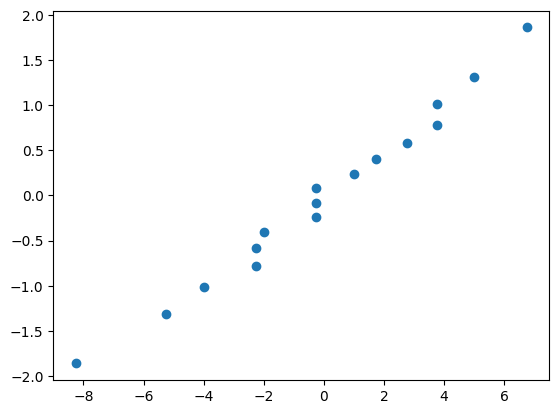

In [46]:
# plot residual - normality plot. no violatin of normality. the model above is adequte
plt.scatter(df_06.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,17)[:-1]+1/32))

In [47]:
# to use the *scipy.stats.f_oneway* method
def f_1way(df, by, measure, ):
    data = df.groupby(by)[measure].apply(list).values
    return stats.f_oneway(*data)

### Problem 8

In [48]:
df_08 = pd.DataFrame({
    'rodding': np.repeat([10,15,20,25],3),
    'strength': [1530,1530,1440,1610,1650,1500,1560,1730,1530,1500,1490,1510]
})

In [49]:
f_1way(df_08, 'rodding', 'strength')

F_onewayResult(statistic=np.float64(1.8653637350705747), pvalue=np.float64(0.21378148596410768))

In [50]:
# a and b: analysis of variance
df_08['ave'] = df_08['strength'].mean()
df_08['t_ave'] = df_08.groupby('rodding')['strength'].transform('mean')

df_08['t_dev'] = df_08['t_ave'] - df_08['ave']
df_08['residual'] = df_08['strength'] - df_08['t_ave']

SST_08 = (df_08.t_dev**2).sum() # sum of squares of treatment deviations, 3 degrees of freedom
MST_08 = SST_08/3 # mean square of treatment deviations, estimate of btw treatment variance

SSE_08 = (df_08.residual**2).sum() # sum of squares of residuals, 8 degrees of freedom
MSE_08 = SSE_08/8 # mean square of treatment deviations. estimate of test variance, within treatment variance

f_08 = MST_08/MSE_08 # f statistic, degrees of freedom, 3 and 8

p_08 = stats.f.sf(f_08, dfn=3, dfd=8)

print(f'The p value of the test is {p_08.round(3)}, larger than the pre-selected {alpha}=0.05. There is no significant difference in compressive strength dueto the rodding level.')

The p value of the test is 0.214, larger than the pre-selected α=0.05. There is no significant difference in compressive strength dueto the rodding level.


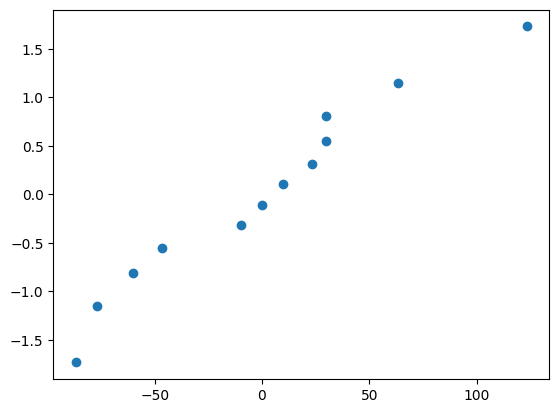

In [51]:
# c check residuals
# plot residual - normality plot. no violatin of normality. the model above is adequte
plt.scatter(df_08.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,13)[:-1]+1/24))

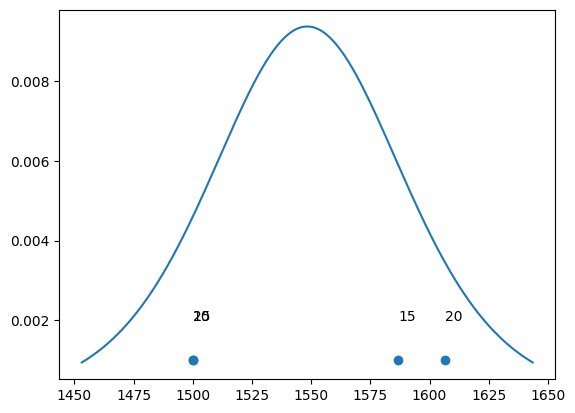

In [52]:
# d coating 2 has the highest conductivity
# generate data to build the t distribution.
loc_08 = df_08['strength'].mean()
scale_08 = np.sqrt(MSE_08/3) # 3 means each sample size is 3. degree of freedom of is the same as that of MSE_08, 8

x_08 = np.linspace(stats.t.isf(0.975, loc=loc_08, scale=scale_08, df=8), stats.t.isf(0.025, loc=loc_08, scale=scale_08, df=8), 1001) # covers 95% confidence interval
y_08 = stats.t.pdf(x_08,loc=loc_08, scale=scale_08, df=8)

# plot
plt.plot(x_08, y_08)
plt.scatter(df_08.groupby('rodding')['strength'].mean(), [0.001]*4)
for i in range(4):
    plt.text(df_08.groupby('rodding')['strength'].mean().values[i], 0.002, df_08.groupby('rodding')['strength'].mean().index[i])
plt.show()

### Example 1

### 

In [53]:
df_s01 = pd.DataFrame({
    'cotton': np.repeat(np.arange(5)*5+15,5),
    'strength': [7,7,15,11,9,12,17,12,18,18,14,18,18,19,19,19,25,22,19,23,7,10,11,15,11]
})

df_s01

,cotton,strength
0,15,7
1,15,7
2,15,15
3,15,11
4,15,9
5,20,12
6,20,17
7,20,12
8,20,18
9,20,18


In [54]:
data_s01 = df_s01.groupby('cotton')['strength'].apply(list).values
stats.f_oneway(data_s01[0], data_s01[1], data_s01[2], data_s01[3], data_s01[4])

F_onewayResult(statistic=np.float64(14.75682382133994), pvalue=np.float64(9.12793712405849e-06))

In [55]:
# a and b: analysis of variance
df_s01['ave'] = df_s01['strength'].mean()
df_s01['t_ave'] = df_s01.groupby('cotton')['strength'].transform('mean')

df_s01['t_dev'] = df_s01['t_ave'] - df_s01['ave']
df_s01['residual'] = df_s01['strength'] - df_s01['t_ave']

SST_s01 = (df_s01.t_dev**2).sum() # sum of squares of treatment deviations, 4 degrees of freedom
MST_s01 = SST_s01/4 # mean square of treatment deviations, estimate of btw treatment variance

SSE_s01 = (df_s01.residual**2).sum() # sum of squares of residuals, 20 degrees of freedom
MSE_s01 = SSE_s01/20 # mean square of treatment deviations. estimate of test variance, within treatment variance

f_s01 = MST_s01/MSE_s01 # f statistic, degrees of freedom, 4 and 20

p_s01 = stats.f.sf(f_s01, dfn=4, dfd=20)

print(f'The p value of the test is {p_s01.round(5)}, smaller than the pre-selected {alpha}=0.05. There is significant difference in compressive strength dueto the rodding level.')

The p value of the test is 1e-05, smaller than the pre-selected α=0.05. There is significant difference in compressive strength dueto the rodding level.


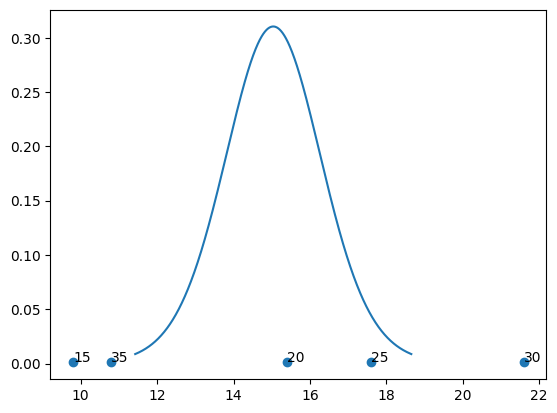

In [56]:
# generate data to build the t distribution.
loc_s01 = df_s01['strength'].mean()
scale_s01 = np.sqrt(MSE_s01/5) # 5 means each sample size is 5. degree of freedom of is the same as that of MSE_s01, 

x_s01 = np.linspace(stats.t.isf(0.995, loc=loc_s01, scale=scale_s01, df=20), stats.t.isf(0.005, loc=loc_s01, scale=scale_s01, df=20), 1001) # covers 95% confidence interval
y_s01 = stats.t.pdf(x_s01,loc=loc_s01, scale=scale_s01, df=20)

# plot
plt.plot(x_s01, y_s01)
plt.scatter(df_s01.groupby('cotton')['strength'].mean(), [0.001]*5)
for i in range(5):
    plt.text(df_s01.groupby('cotton')['strength'].mean().values[i], 0.002, df_s01.groupby('cotton')['strength'].mean().index[i])
plt.show()

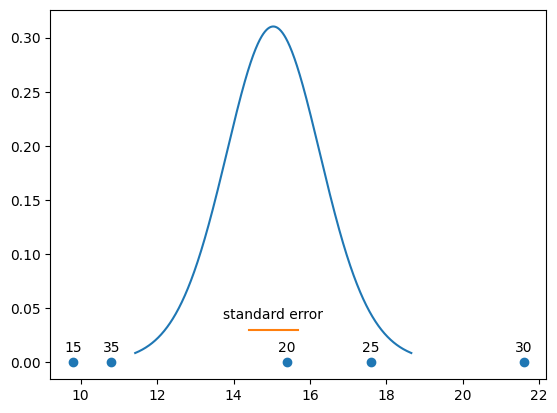

In [57]:
from graphical_comp_mean import graphical_comp_mean
fig,ax=graphical_comp_mean(df_s01, 'cotton', 'strength', 0.01)

### Problem 9

* from problem 9, I am going to just use the **scipy.stats.f_oneway** method

In [58]:
df_09 = pd.DataFrame({
    'dia': np.repeat([0.37,0.51,0.71,1.02,1.40,1.99],4),
    'radon': [80,83,83,85,75,75,79,79,74,73,76,77,67,72,74,74,62,62,67,69,60,61,64,66]
})

In [59]:
# a analysis of variance
f_09, p_09 = f_1way(df_09, 'dia', 'radon')
print(f'The p value for the test is <{1e-7}, smaller than the pre-selected {alpha}=0.05. The size of the orifice affect the mean precentage of radon released.')

The p value for the test is <1e-07, smaller than the pre-selected α=0.05. The size of the orifice affect the mean precentage of radon released.


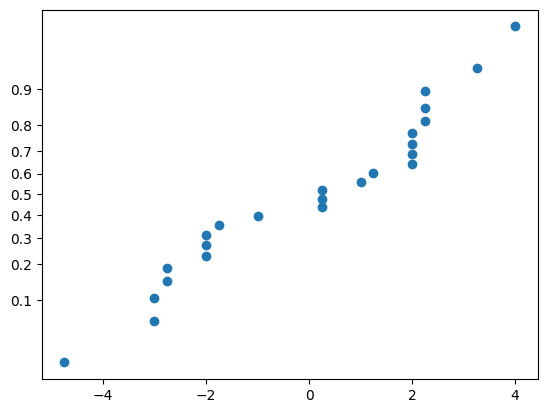

In [60]:
# c check residuals with normality plot
# The plot shows no violations of normality
df_09['t_ave'] = df_09.groupby('dia')['radon'].transform('mean')
df_09['residual'] = df_09['radon'] - df_09['t_ave']

plt.scatter(df_09.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,25)[:-1]+1/48))
plt.yticks(-stats.norm.isf(np.linspace(0.1,0.9,9)), np.linspace(0.1,0.9,9).round(2))
plt.show()

In [61]:
# d 
r_ave_09d = df_09[df_09['dia']==1.40]['radon'].mean() # the mean percent of radon released wht the diameter is 1.40
r_se_09d = np.sqrt((df_09.residual**2).sum()/(24-6)/4) # the standard error of the mean, with 18 degrees of freedom
t_09d = stats.t.sf(0.05/2, df=18) # the corresponding t statistic at right tail
print(f'The 95% confidence interval on the mean is from {(r_ave_09d-t_09d*r_se_09d).round(1)} to {(r_ave_09d + t_09d*r_se_09d).round(1)}')

The 95% confidence interval on the mean is from 64.3 to 65.7


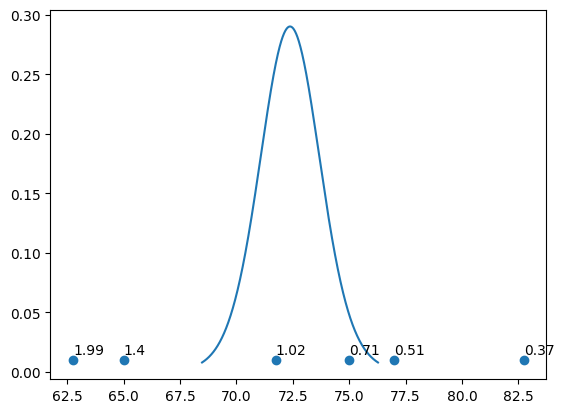

In [62]:
# e
# generate the data to plot the t distribution
loc_09e = df_09.radon.mean() # the center of the t distribution
scale_09e = r_se_09d # the scale of the t distribution is just the standard error of the sample mean

# create a range of x 
pct_09e = 0.99 # the coverage of the range x
t_09e = stats.t.isf((1-pct_09e)/2, scale=scale_09e, df=18) # 
x_09e = np.linspace(-t_09e, t_09e, 1001)
y_09e = stats.t.pdf(x_09e, scale=scale_09e, df=18)

# generate the t distribution plot
plt.plot(x_09e+loc_09e, y_09e)

# plot the data scatter plots
r_ave_09 = df_09.groupby('dia')['radon'].mean()
plt.scatter(r_ave_09.values, [0.01]*6)
for i in range(6):
    plt.text(r_ave_09.values[i], 0.015, r_ave_09.index[i])

### Problem 10

In [63]:
df_10 = pd.DataFrame({
    'circuit': np.repeat([1,2,3],5),
    'r_time': [9,12,10,8,15,20,21,23,17,30,6,5,8,16,7]
})

In [64]:
# a. The null hypothesis (H0): the three circuit types have the same response time and alpha=0.01
# run analysis of variance using the scipy.stats.f_oneway method
f_10a, p_10a = f_1way(df_10, 'circuit', 'r_time')
f_10a, p_10a
print(f'The p value of the test is {p_10a.round(4)}, smaller than the pre-selected {alpha}=0.01. The null hypothesis is safe to reject.')

The p value of the test is 0.0004, smaller than the pre-selected α=0.01. The null hypothesis is safe to reject.


In [65]:
# b. Tukey's test with equal sample sizes

In [66]:
from tukey import tukey
df_q_10 = tukey(df_10, 'circuit', 'r_time', 0.01) # find the 3 q statistics for the 3 pairs

In [67]:
df_q_10

,pair,q
0,"(1, 2)",-6.200783
1,"(1, 3)",1.305428
2,"(2, 1)",6.200783
3,"(2, 3)",7.506210
4,"(3, 1)",-1.305428
5,"(3, 2)",-7.506210
6,critical_q,5.045935


In [68]:
print(stats.tukey_hsd(*(df_10.groupby('circuit')['r_time'].apply(list).values)))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -11.400     0.002   -18.336    -4.464
 (0 - 2)      2.400     0.637    -4.536     9.336
 (1 - 0)     11.400     0.002     4.464    18.336
 (1 - 2)     13.800     0.001     6.864    20.736
 (2 - 0)     -2.400     0.637    -9.336     4.536
 (2 - 1)    -13.800     0.001   -20.736    -6.864



In [69]:
# alpha=0.01, find the critial q(0.01,15) from Appendix 
print(f'The critical q statistic at {alpha}=0.01 and 12 degrees of freedom is 5.05. The q statistic of pair 1vs2 and 2vs3 are larger, therefore there are significant differences btw 1 and 2, 2 and 3')

The critical q statistic at α=0.01 and 12 degrees of freedom is 5.05. The q statistic of pair 1vs2 and 2vs3 are larger, therefore there are significant differences btw 1 and 2, 2 and 3


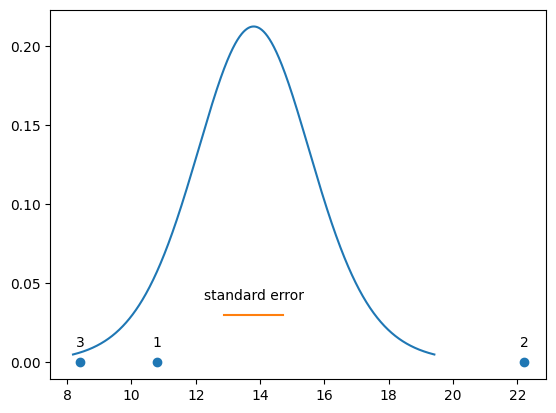

In [70]:
# c use the graphical_comp_mean function
# conclusion same as Tukey's test
fig_10c, ax_10c = graphical_comp_mean(df_10, 'circuit', 'r_time', 0.01)

d. construct the orthoganol contrasts
* $\mu_1 = \mu_3$, $C_1 = \mu_1 - \mu_3$
* $2\mu_2 = \mu_1+\mu_3$, $C_2 = \mu_1 + \mu_3 -2\mu_2$
* $$F_0 = t_0^2 = \frac{(\sum_0^a c_i y_{i.})^2}{nMS_E\sum_0^ac_i^2} = \frac{(\sum_0^a c_i n \bar{y}_i)^2}{MS_E\sum_0^anc_i^2} $$

In [71]:
# d
# calculate the two contrast
C_10d_1 = df_10[df_10['circuit']==1]['r_time'].mean() - df_10[df_10['circuit']==3]['r_time'].mean()
C_10d_2 = df_10[df_10['circuit']==1]['r_time'].mean() + df_10[df_10['circuit']==3]['r_time'].mean() - 2 * df_10[df_10['circuit']==2]['r_time'].mean()
C_10d_1, C_10d_2

(np.float64(2.4000000000000004), np.float64(-25.199999999999996))

In [72]:
# calcualte the F statistics and the corresponding critial statistics of the two contrast
df_10['C1'] = np.repeat([1,0,-1],5)
df_10['C2'] = np.repeat([1,-2,1],5)
MSE_10 = (df_10['residual']**2).sum() / 12
F_10d_1 = (df_10['C1'] * df_10['t_ave']).sum()**2 / MSE_10 / (df_10['C1']**2).sum()
F_10d_2 = (df_10['C2'] * df_10['t_ave']).sum()**2 / MSE_10 / (df_10['C2']**2).sum()
F_10d_12 = (F_10d_1 + F_10d_2)/2 # sum of squares C1 + C2
F_10d_critial = stats.f.isf(0.05,dfn=1, dfd=12)
F_10d_critial2 = stats.f.isf(0.05,dfn=2, dfd=12)
F_10d_1, F_10d_2, F_10d_critial, F_10d_12, F_10d_critial2

(np.float64(0.8520710059171606),
 np.float64(31.31360946745561),
 np.float64(4.747225346722515),
 np.float64(16.082840236686387),
 np.float64(3.8852938346523924))

Conclusion of d: no significant difference btw 1 and 3 and significant difference btw 2 and the average of 1 and 3

In [73]:
# e recommend 1 or 3
df_10

,circuit,r_time,ave,t_ave,residual,C1,C2
0,1,9,13.8,10.8,-1.8,1,1
1,1,12,13.8,10.8,1.2,1,1
2,1,10,13.8,10.8,-0.8,1,1
3,1,8,13.8,10.8,-2.8,1,1
4,1,15,13.8,10.8,4.2,1,1
5,2,20,13.8,22.2,-2.2,0,-2
6,2,21,13.8,22.2,-1.2,0,-2
7,2,23,13.8,22.2,0.8,0,-2
8,2,17,13.8,22.2,-5.2,0,-2
9,2,30,13.8,22.2,7.8,0,-2


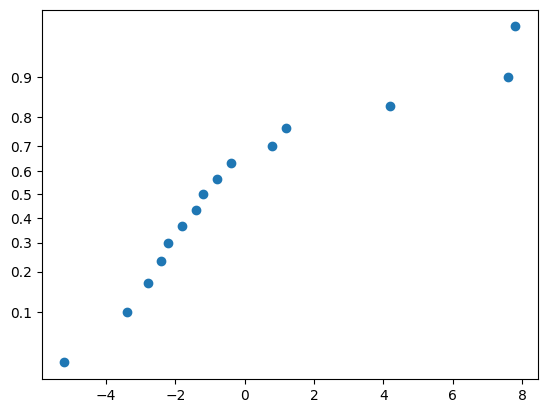

There is strong violation of the normality assumption.


In [74]:
# f check the residuals
plt.scatter(df_10.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,16)[:-1]+1/30))
plt.yticks(-stats.norm.isf(np.linspace(0.1,0.9,9)), np.linspace(0.1,0.9,9).round(2))
plt.show()
print('There is strong violation of the normality assumption.')


### Problem 11 

In [75]:
df_11 = pd.DataFrame({
    'fluid': np.repeat([1,2,3,4],6),
    'life': [17.6,18.9,16.3,17.4,20.1,21.6,16.9,15.3,18.6,17.1,19.5,20.3,21.4,23.6,19.4,18.5,20.5,22.3,19.3,21.1,16.9,17.5,18.3,19.8]
})

In [76]:
# use the stats.f_oneway method for analysis of variance
# no significant difference at alpha=0.05 significance level
stats.f_oneway(*df_11.groupby('fluid')['life'].apply(list).values)

F_onewayResult(statistic=np.float64(3.047277502778055), pvalue=np.float64(0.05246315875744821))

In [77]:
# double check with mannually analysis of variance
df_11['ave']=df_11['life'].mean()
df_11['t_ave'] = df_11.groupby('fluid')['life'].transform('mean')
df_11['t_dev'] = df_11['t_ave'] - df_11['ave']
df_11['residual'] = df_11['life'] - df_11['t_ave']

SSE_11 =( df_11.residual**2).sum() # sum of squares of all residuals, degree of freedom (24-4)=20
MSE_11 = SSE_11/20

SST_11 = (df_11.t_dev**2).sum() # sum of squares of btw treatment deviations, 3 degrees of freedom
MST_11 = SST_11/3

f_11a = MST_11 / MSE_11
p_11a = stats.f.sf(f_11a, dfn=3, dfd=20)

print(f'The p value for the test is {p_11a.round(3)}, slightly larger than the pre-seleted {alpha}=0.05. There is not enough evidence to reject the null hypothesis of no significant differences')

The p value for the test is 0.052, slightly larger than the pre-seleted α=0.05. There is not enough evidence to reject the null hypothesis of no significant differences


In [78]:
# b recommend one fluid.
# use the stats.tukey_hsd method to evaluate the differences (so here the 'statistic' result from the tukey_hsd method are the mean difference, not the actual q statistic)
print(stats.tukey_hsd(*df_11.groupby('fluid')['life'].apply(list).values))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.700     0.908    -2.235     3.635
 (0 - 2)     -2.300     0.159    -5.235     0.635
 (0 - 3)     -0.167     0.999    -3.102     2.769
 (1 - 0)     -0.700     0.908    -3.635     2.235
 (1 - 2)     -3.000     0.044    -5.935    -0.065
 (1 - 3)     -0.867     0.841    -3.802     2.069
 (2 - 0)      2.300     0.159    -0.635     5.235
 (2 - 1)      3.000     0.044     0.065     5.935
 (2 - 3)      2.133     0.209    -0.802     5.069
 (3 - 0)      0.167     0.999    -2.769     3.102
 (3 - 1)      0.867     0.841    -2.069     3.802
 (3 - 2)     -2.133     0.209    -5.069     0.802



In [79]:
# use the tukey method to evaluate the differences
tukey(df_11, 'fluid', 'life', 0.05)

,pair,q
0,"(1, 2)",0.943927
1,"(1, 3)",-3.101476
2,"(1, 4)",-0.224745
3,"(2, 1)",-0.943927
4,"(2, 3)",-4.045403
5,"(2, 4)",-1.168672
6,"(3, 1)",3.101476
7,"(3, 2)",4.045403
8,"(3, 4)",2.876731
9,"(4, 1)",0.224745


It is clear that the life time of fluid 3 is significant larger than that of the other 3. I would recommend fluid 3 based on the analysis above.


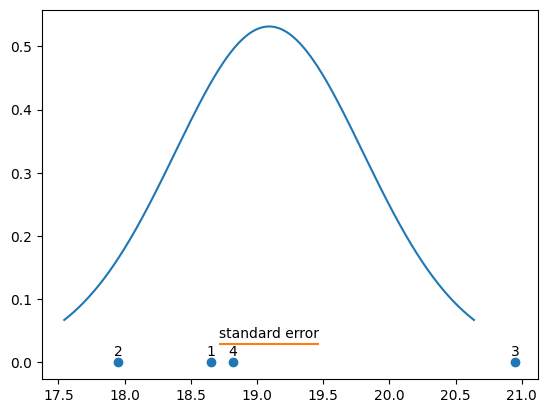

In [80]:
# use the graphical comparison of means to evaluate the differences
graphical_comp_mean(df_11, 'fluid', 'life', 0.05)
print('It is clear that the life time of fluid 3 is significant larger than that of the other 3. I would recommend fluid 3 based on the analysis above.')

very mild violation of normality


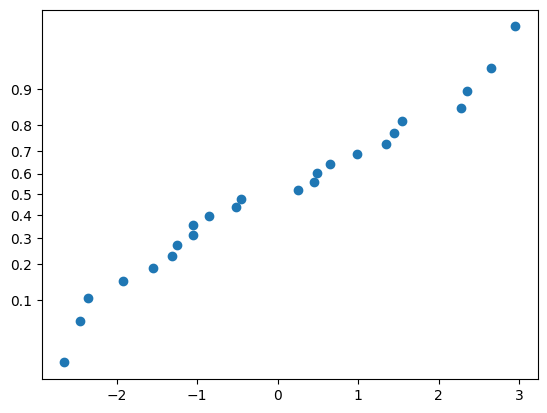

In [81]:
#c check residuals by plot the normality plot.
# very mild violation of normality
from normality_plot import normality_plot
normality_plot(df_11.residual)
print('very mild violation of normality')

### Problem 12

In [82]:
df_12 = pd.DataFrame({
    'circuit': np.repeat(np.arange(1,5),5),
    'noise': [19,20,19,30,8,80,61,73,56,80,47,26,25,35,50,95,46,83,89,97]
})

In [83]:
#a. one way anova with stats.f_oneway. 
f_12a, p_12a = stats.f_oneway(*df_12.groupby('circuit')['noise'].apply(list).values)
print(f'The p value of the test is {p_12a.round(5)}, lower than the pre-selected {alpha}=0.05. There is strong evidence that the amount of noise is not the same')

The p value of the test is 1e-05, lower than the pre-selected α=0.05. There is strong evidence that the amount of noise is not the same


There is strong violation of normality assumption.


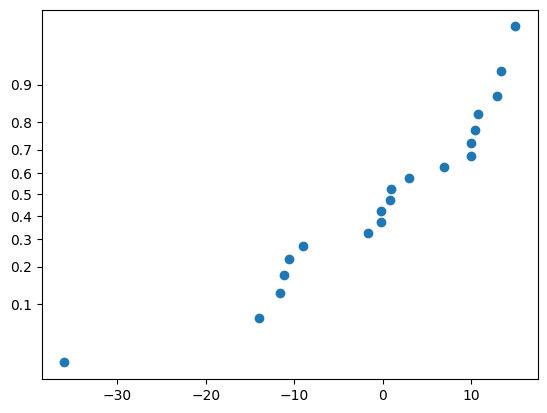

In [84]:
#b. check residuals with the normality plot
normality_plot(df_12.noise - df_12.groupby('circuit')['noise'].transform('mean'))
print('There is strong violation of normality assumption.')


In [85]:
#c. 
tukey(df_12, 'circuit', 'noise', 0.05)

,pair,q
0,"(1, 2)",-8.287322
1,"(1, 3)",-2.838571
2,"(1, 4)",-10.244957
3,"(2, 1)",8.287322
4,"(2, 3)",5.448751
5,"(2, 4)",-1.957635
6,"(3, 1)",2.838571
7,"(3, 2)",-5.448751
8,"(3, 4)",-7.406386
9,"(4, 1)",10.244957


from tukey test and the graphical comparison of means, circuit 1 gives the lowest noise


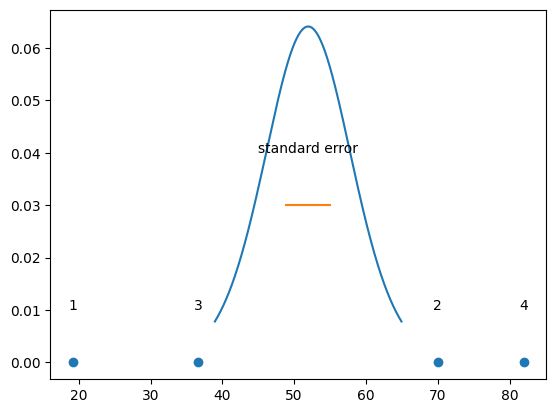

In [86]:
graphical_comp_mean(df_12, 'circuit', 'noise', 0.05)
print('from tukey test and the graphical comparison of means, circuit 1 gives the lowest noise')

### Problem 13

In [87]:
df_13 = pd.DataFrame({
    'chem': np.repeat(np.arange(1,5),3),
    'pct': [84.99,84.04,84.38,85.15,85.13,84.88,84.72,84.48,85.16,84.2,84.1,84.55]
})

In [88]:
#a. analysis of variance to check if the chemists differ
f_12a, p_12a = stats.f_oneway(*df_13.groupby('chem')['pct'].apply(list).values)
print(f'The f statistic for the test is {f_12a.round(3)}, and the p value for the test is {p_12a.round(3)}. The pre-selected {alpha}=0.05. Thus, the chemists do not differ significantly')

The f statistic for the test is 3.246, and the p value for the test is 0.081. The pre-selected α=0.05. Thus, the chemists do not differ significantly


The normality assumption is valid according to the normality plot below


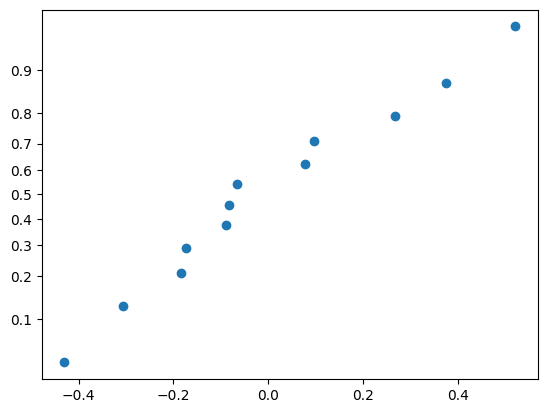

In [89]:
# b. analyze residuals to check normality
normality_plot(df_13['pct'] - df_13.groupby('chem')['pct'].transform('mean'))
print('The normality assumption is valid according to the normality plot below')

c. The set of contrast
* $\mu_1 = \mu_3$, $C_1 = \mu_1 - \mu_3$
* $\mu_1 + \mu_3 = 2\mu_4$, $C_2 = \mu_1 + \mu_3 - 2\mu_4$
* $3\mu_2 = \mu_1 + \mu_3 + \mu_4$, $C_3 = \mu_1 - 3\mu_2 + \mu_3 + \mu_4$



In [90]:
# add the contrast coeffients to the dataframe
df_13['C1'] = np.repeat([1,0,-1,0],3)
df_13['C2'] = np.repeat([1,0,1,-2],3)
df_13['C3'] = np.repeat([1,-3,1,1],3)

In [91]:
sse_13 = ((df_13.pct - df_13.groupby('chem')['pct'].transform('mean'))**2).sum() # (12-4)=8 degrees of freedom
mse_13 = sse_13 / 8
mse_13

np.float64(0.10727499999999841)

In [92]:
# contrast sum of squares (each with 1 degree of freedom). 
ssc_13 = []
f_13 = []
p_13 = []
for c in ['C1', 'C2', 'C3']:
    ssc = (df_13[c]*df_13['pct']).sum()**2 / (df_13[c]**2).sum()
    ssc_13.append(ssc)
    f_13.append(ssc/mse_13)
    p_13.append(stats.f.sf(ssc/mse_13, dfn=1, dfd=8))

# sum of the orthoganol contrast set
ssc_13.append(sum(ssc_13))
f_13.append(ssc_13[-1]/3/mse_13)
p_13.append(stats.f.sf(f_13[-1], dfn=3, dfd=8))


df_13c = pd.DataFrame({
    'C': ['C1', 'C2', 'C3', 'C123'],
    'ssc': ssc_13,
    'f_statistic': f_13,
    'p_value': p_13
})

print(df_13c, '\nThere is not signifcant difference btw chemist 1 and 3, 4 and the average of 1 and 3. There is significant difference btw 2 and the average 1,3,and 4.')

      C       ssc  f_statistic   p_value
0    C1  0.150417     1.402160  0.270349
1    C2  0.238050     2.219063  0.174645
2    C3  0.656100     6.116057  0.038526
3  C123  1.044567     3.245760  0.081290 
There is not signifcant difference btw chemist 1 and 3, 4 and the average of 1 and 3. There is significant difference btw 2 and the average 1,3,and 4.


### Problem 14

In [93]:
df_14 = pd.DataFrame({
    'brand': np.repeat([1,2,3],5),
    'weeks': [100,96,92,96,92,76,80,75,84,82,108,100,96,98,100]
})

In [94]:
# a analyze the difference with one way anova stats.f_oneway
# set alpha=0.05
f_14a, p_14a = stats.f_oneway(*df_14.groupby('brand')['weeks'].apply(list).values)
print(f'The F statistic for the test is {f_14a.round(3)} and the p value is {p_14a.round(3)}. The p value is smaller than the pre-selectred {alpha}=0.05, meaning significant differences among brands')

The F statistic for the test is 38.338 and the p value is 0.0. The p value is smaller than the pre-selectred α=0.05, meaning significant differences among brands


No significant violation of the normality assumption


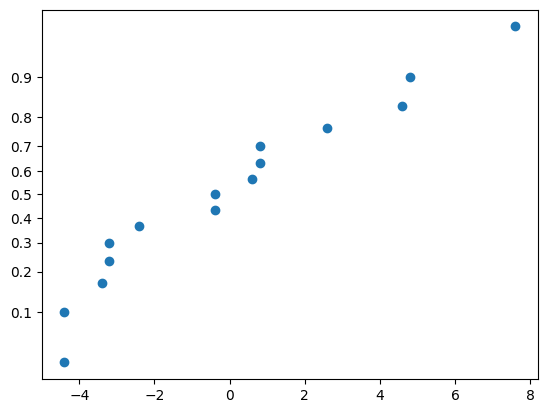

In [95]:
# b check residuals with normality plot
normality_plot(df_14.weeks-df_14.groupby('brand')['weeks'].transform('mean'))
print('No significant violation of the normality assumption')

In [96]:
#c 
# 95% confidence interval on the mean life of battery brand 2
mean_14_2 = df_14[df_14['brand']==2]['weeks'].mean()
sse_14 = ((df_14.weeks-df_14.groupby('brand')['weeks'].transform('mean'))**2).sum()
mse_14 = sse_14 / (3*5-3)
t_14c = stats.t.isf(0.05/2, df=12)

print(f'The 95% confidence interval on the mean life of battery brand 2 is from {(mean_14_2-t_14c*np.sqrt(mse_14/5)).round(1)} to {(mean_14_2 + t_14c*np.sqrt(mse_14/5)).round(1)}')

The 95% confidence interval on the mean life of battery brand 2 is from 75.6 to 83.2


In [97]:
# c 
# 99% confidence interval on the mean difference btw brand 2 and 3
mean_14_d23 = np.abs(df_14[df_14['brand']==2]['weeks'].mean() - df_14[df_14['brand']==3]['weeks'].mean())
t_14c_d23 = stats.t.isf(0.01/2, df=12)
print(f'The 95% confidence interval on the mean life difference btw brand 2 and 3 is from {(mean_14_d23 - t_14c_d23*np.sqrt(mse_14*(1/5+1/5))).round(1)} to {(mean_14_d23 + t_14c_d23*np.sqrt(mse_14*(1/5+1/5))).round(1)}')

The 95% confidence interval on the mean life difference btw brand 2 and 3 is from 13.4 to 28.6


In [98]:
# d. I would select brand 3 as show below.
print('I would select brand 3 which shows the highest lifetime mean\n',
      df_14.groupby('brand')['weeks'].mean().to_frame())

I would select brand 3 which shows the highest lifetime mean
        weeks
brand       
1       95.2
2       79.4
3      100.4


In [99]:
#d. the battery lifetime follows the t distribution with variance of MSE_14 and 12 degrees of freedom
print(f'The percentage of batteries expcted to be replaced is {(1-stats.t.sf((85-df_14.groupby('brand')['weeks'].mean().max())/np.sqrt(mse_14), df=12)):.2%}')

The percentage of batteries expcted to be replaced is 0.11%


### Problem 15

In [100]:
df_15 = pd.DataFrame({
    'catalyst': [1]*5+[2]*4+[3]*3+[4]*4,
    'conc': [58.2,57.2,58.4,55.8,54.9,56.3,54.5,57.,55.3,50.1,54.2,55.4,52.9,49.9,50.0,51.7]
})

In [101]:
# a analysis of variance with stats.f_oneway
f_15a, p_15a = stats.f_oneway(*df_15.groupby('catalyst')['conc'].apply(list).values)
print(f'The f statistic and the p value is {f_15a.round(2)} and {p_15a.round(4)}. If the pre-selectd {alpha}=0.05, the four catalysts do NOT have the same effect on the concentration.')

The f statistic and the p value is 9.92 and 0.0014. If the pre-selectd α=0.05, the four catalysts do NOT have the same effect on the concentration.


There is mild violation of the normality assumption.


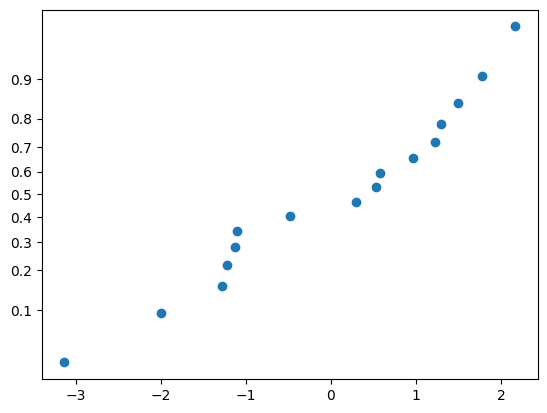

In [102]:
# b analyse the residuals by making the normality plot
df_15['residual'] = df_15['conc'] - df_15.groupby('catalyst')['conc'].transform('mean')
fig_15b, ax_15b = normality_plot(df_15['residual'])
print('There is mild violation of the normality assumption.')

In [103]:
# c
sse_15 = (df_15.residual**2).sum() # 16-4 = 12 degree of freedom
mse_15 = sse_15/12
mean_15c = df_15[df_15['catalyst']==1]['conc'].mean()
print(f'The 99% confidence interval on the mean response for catalyst 1 is from {(mean_15c - stats.t.isf(0.01/2,df=12)*np.sqrt(mse_15/5)).round(1)} to {(mean_15c + stats.t.isf(0.01/2,df=12)*np.sqrt(mse_15/5)).round(1)}')

The 99% confidence interval on the mean response for catalyst 1 is from 54.6 to 59.2


### Problem 16

In [104]:
df_16 = pd.DataFrame({
    'mat': np.repeat(np.arange(1,6),4),
    'f_time': [110,157,194,178,1,2,4,18,880,1256,5276,4355,495,7040,5307,10050,7,5,29,2]
})

In [105]:
# a. one-way ANOVA with the stats.f_oneway
f_16a, p_16a = stats.f_oneway(*df_16.groupby('mat')['f_time'].apply(list).values)
print(f'The f statistic and the p value is {f_16a.round(2)} and {p_16a.round(4)}. If the pre-selectd {alpha}=0.05, the 5 materials do NOT have the same effect on the mean failure time.')

The f statistic and the p value is 6.19 and 0.0038. If the pre-selectd α=0.05, the 5 materials do NOT have the same effect on the mean failure time.


The data significantly violates the normality assumptions. The ONE-WAY ANOVA analysis is compromised


(<Figure size 640x480 with 1 Axes>, <Axes: >)

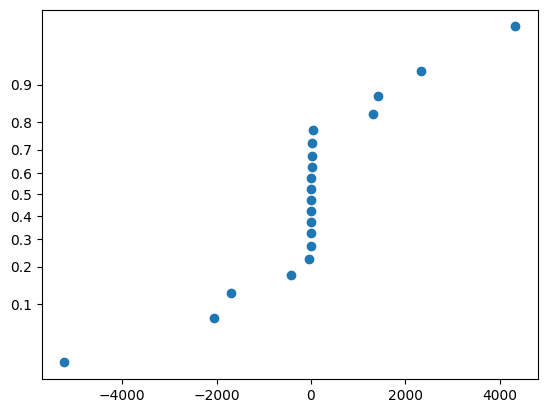

In [106]:
# check residuals
print('The data significantly violates the normality assumptions. The ONE-WAY ANOVA analysis is compromised')
normality_plot(df_16['f_time'] - df_16.groupby('mat')['f_time'].transform('mean'))


      The residual increases as the predicted value or treatment average increases.
      This is consistent with the residual plot above.
      There is significant violation of the normality assumption.
      


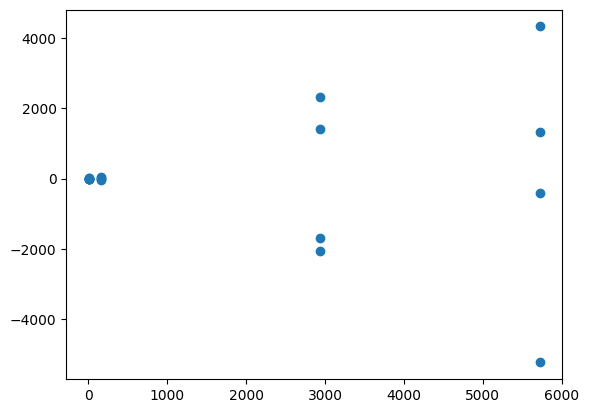

In [107]:
# b. check residuals against predicted responses (the treatment average)
print('''
      The residual increases as the predicted value or treatment average increases.
      This is consistent with the residual plot above.
      There is significant violation of the normality assumption.
      ''')
plt.scatter(df_16.groupby('mat')['f_time'].transform('mean'), df_16['f_time'] - df_16.groupby('mat')['f_time'].transform('mean'))


      The plot below - the natrual log of residual agains the natrual log of predicted value, shows a straight line with a slope of about 1.
      So the log transformation is proper for the transformatin of the original data. 


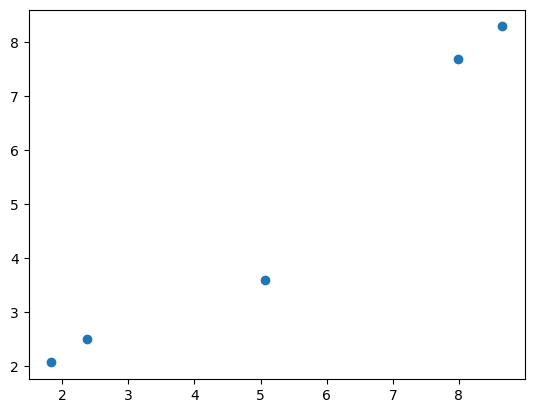

In [108]:
# c. 
print('''
      The plot below - the natrual log of residual agains the natrual log of predicted value, shows a straight line with a slope of about 1.
      So the log transformation is proper for the transformatin of the original data. ''')
plt.scatter(np.log(df_16.groupby('mat')['f_time'].mean()), np.log(df_16.groupby('mat')['f_time'].std(ddof=1)))

In [109]:
# c check the residuals for the transformed data
print('The transformed data shows no violation of the normality assumption.')
normality_plot(df_16['f_time_log'] - df_16.groupby('mat')['f_time_log'].transform('mean'))

The transformed data shows no violation of the normality assumption.


KeyError: 'f_time_log'


      The residuals of the transformed data look better.
      This is consistent with the residual plot above.
      There is no significant violation of the normality assumption.
      


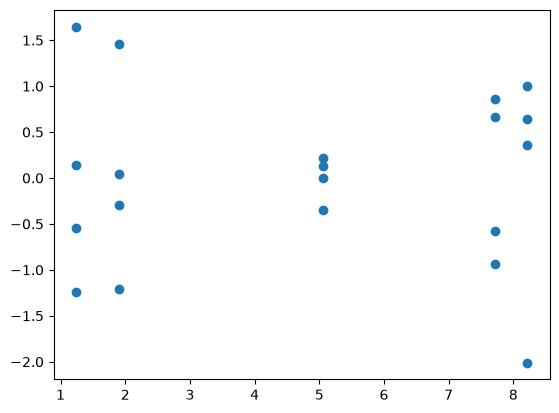

In [ ]:
print('''
      The residuals of the transformed data look better.
      This is consistent with the residual plot above.
      There is no significant violation of the normality assumption.
      ''')
plt.scatter(df_16.groupby('mat')['f_time_log'].transform('mean'), df_16['f_time_log'] - df_16.groupby('mat')['f_time_log'].transform('mean'))

In [ ]:
# c
# a. one-way ANOVA with the stats.f_oneway on the transformed data
df_16['f_time_log'] = df_16['f_time'].apply(np.log)
f_16c, p_16c = stats.f_oneway(*df_16.groupby('mat')['f_time_log'].apply(list).values)
print(f'The f statistic and the p value is {f_16c.round(2)} and {p_16c.round(8)}. If the pre-selectd {alpha}=0.05, the 5 materials do NOT have the same effect on the mean failure time.')

The f statistic and the p value is 37.66 and 1.2e-07. If the pre-selectd α=0.05, the 5 materials do NOT have the same effect on the mean failure time.


### Problem 17

In [ ]:
df_17 = pd.DataFrame({
    'method': np.repeat([1,2,3],5),
    'p_count': [31,10,21,4,1,62,40,24,30,35,53,27,120,97,68]
})

In [ ]:
# a Analysis of variance with stats.f_oneway. select alpha=0.05
f_17a, p_17a = stats.f_oneway(*df_17.groupby('method')['p_count'].apply(list).values)
print(f'The f statistic and p value of the test is {f_17a.round(3)} and {p_17a.round(4)}. The three methods do not have the same effect.')

The f statistic and p value of the test is 7.914 and 0.0064. The three methods do not have the same effect.


moderate violation of the normality assumptions


(<Figure size 640x480 with 1 Axes>, <Axes: >)

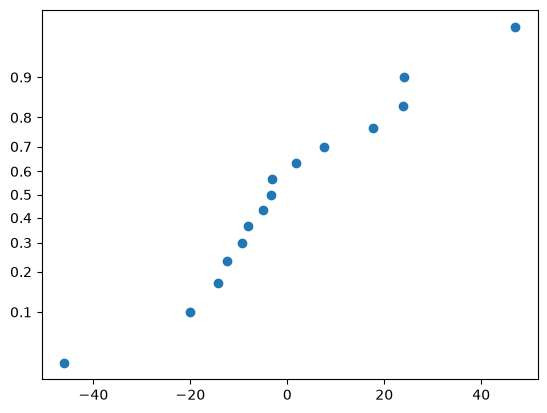

In [ ]:
# b check the residual
print('moderate violation of the normality assumptions')
normality_plot(df_17['p_count'] - df_17.groupby('method')['p_count'].transform('mean'))

Clearly, the residual increases as the predicted particle count (the treatment average) increases. This is consistent with the normality plot.
The one-way ANOVA might not be valid.


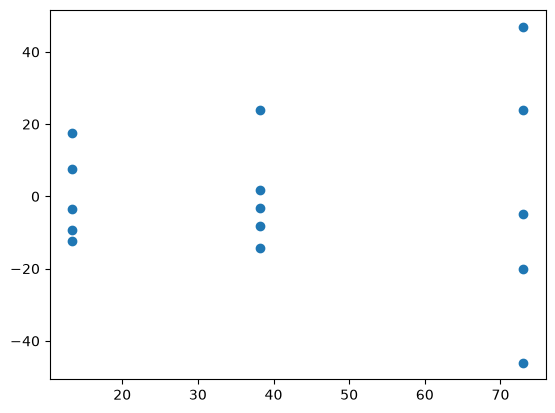

In [ ]:
#b
print('Clearly, the residual increases as the predicted particle count (the treatment average) increases. This is consistent with the normality plot.')
print('The one-way ANOVA might not be valid.')
plt.scatter(df_17.groupby('method')['p_count'].transform('mean'), df_17['p_count'] - df_17.groupby('method')['p_count'].transform('mean'))


      The plot below - the natrual log of residual agains the natrual log of predicted value, shows a straight line with a slope of about 1.
      So the log transformation is proper for the transformatin of the original data. 


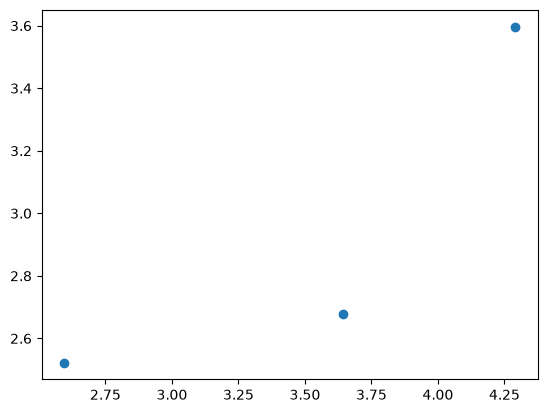

In [ ]:
# c. 
print('''
      The plot below - the natrual log of residual agains the natrual log of predicted value, shows a straight line with a slope of about 1.
      So the log transformation is proper for the transformatin of the original data. ''')
plt.scatter(np.log(df_17.groupby('method')['p_count'].mean()), np.log(df_17.groupby('method')['p_count'].std(ddof=1)))

In [ ]:
# c run the data transformation and check residual again
print('The transformed data show no significant violation of the normality assumption as shown in the plots below')
df_17['p_count_log'] = np.log(df_17['p_count'])

The transformed data show no significant violation of the normality assumption


(<Figure size 640x480 with 1 Axes>, <Axes: >)

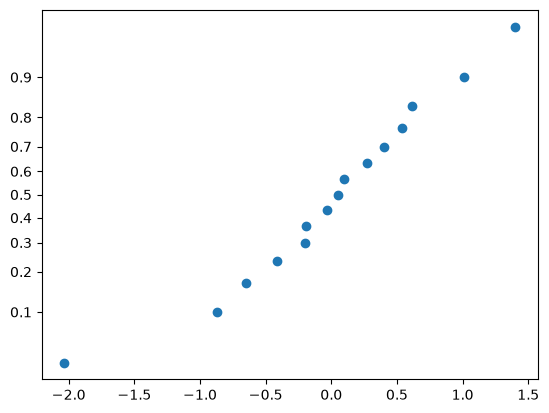

In [ ]:
# c
normality_plot(df_17['p_count_log'] - df_17.groupby('method')['p_count_log'].transform('mean'))

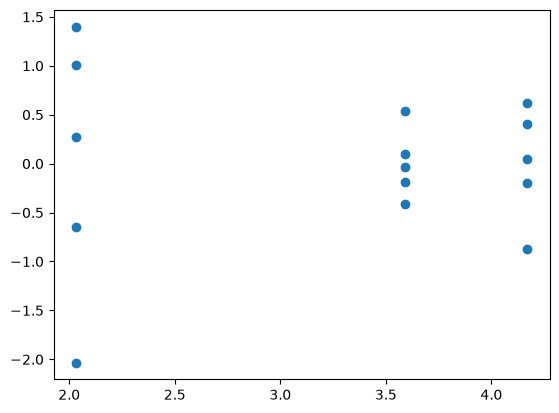

In [ ]:
# c
plt.scatter(df_17.groupby('method')['p_count_log'].transform('mean'), df_17['p_count_log'] - df_17.groupby('method')['p_count_log'].transform('mean'))

In [ ]:
# c one way ANOVA on the transformed data
f_17c, p_17c = stats.f_oneway(*df_17.groupby('method')['p_count_log'].apply(list).values)
print(f'The f statistic and the p value is {f_17c.round(3)} and {p_17c.round(5)}. The three methods do not have the same effect.')
print('If comparing f statistics or p values from a and c, they are very close. The transformation might not be necessary in this case.')

The f statistic and the p value is 7.735 and 0.00695. The three methods do not have the same effect.
If comparing f statistics or p values from a and c, they are very close. The transformation might not be necessary in this case.


### Problem 18

#### Assume 
* The two normal populations are A and B with population means of $\mu_A$ and $\mu_B$.
* Sample size for A and B are $n_A$ and $n_B$
* The sample variances are $V_A$ and $V_B$
* The sample means are $\bar{y}_A$ and $\bar{y}_B$
* The null hypothesis ($H_0$): $\mu_A = \mu_B$ and the alternative hypothesis ($H_0$): $\mu_A \ne \mu_B$

#### The pooled t test
* t statistic with $n_A+n_B-2$ degrees of freedom
$$t_0 = \frac{\bar{y}_A - \bar{y}_B}{\sqrt{\frac{V_A(n_A-1)+V_B(n_B-1)}{n_A+n_B-2}}\sqrt{\frac{1}{n_A} + \frac{1}{n_B}}}$$

#### The single factor analysis of variance
* F statistic with $1, (n_A+n_B-2)$ degrees of freedom

$$F_0 = \frac{MST}{MSE}$$
where $MST$ is the mean square of the treatment deviations and $MSE$ is the mean square of residuals

The grand average of the two samples is $\bar{y} = \frac{n_A\bar{y}_A + n_B\bar{y}_B}{n_A + n_B}$
$$MST = n_A(\bar{y}_A - \bar{y})^2 + n_B(\bar{y}_B - \bar{y})^2 $$
$$MST = n_A(n_B \frac{n_A\bar{y}_A + n_B\bar{y}_B}{n_A + n_B})^2 + n_B(\bar{y}_B - \frac{n_A\bar{y}_A + n_B\bar{y}_B}{n_A + n_B})^2$$
$$MST = n_A(\frac{n_B(\bar{y}_A - \bar{y}_B)}{n_A + n_B})^2 + n_B(\frac{n_A(\bar{y}_A - \bar{y}_B)}{n_A + n_B})^2 $$
$$MST = \frac{(n_A n_B^2 + n_A^2 n_B) (\bar{y}_A - \bar{y}_B)^2}{(n_A + n_B)^2} $$
$$MST = \frac{(n_A n_B + n_A n_B) (\bar{y}_A - \bar{y}_B)^2}{n_A + n_B} $$
$$MST = \frac{(\bar{y}_A - \bar{y}_B)^2}{\frac{1}{n_A} + \frac{1}{n_B}} $$


$$MSE = \frac{V_A(n_A-1)+V_B(n_B-1)}{n_A+n_B-2}$$

$$F_0 = \frac{MST}{MSE} = \frac{\frac{(\bar{y}_A - \bar{y}_B)^2}{\frac{1}{n_A} + \frac{1}{n_B}}}{\frac{V_A(n_A-1)+V_B(n_B-1)}{n_A+n_B-2}} = \frac{(\bar{y}_A - \bar{y}_B)^2}{\frac{V_A(n_A-1)+V_B(n_B-1)}{n_A+n_B-2}(\frac{1}{n_A} + \frac{1}{n_B})}$$

$$F_0 = t_0^2$$

### Problem 19

$$\sum_{i=1}^a c_i y_{i.} = \sum_{i=1}^a c_i \sum_{j=1}^n y_{ij}$$
* The variance of $y$ is $\sigma_2$
* For each $i$, the variance of $\sum_{j=1}^n y_{ij}$ is $n_i \sigma^2$
* For each $i$, the variance of $c_i \sum_{j=1}^n y_{ij}$ is $c_i^2 n_i \sigma^2$
* Therefore, the variance of $\sum_{i=1}^a c_i y_{i.}$ is $\sum_{i=0}^ac_i^2 n_i \sigma^2 = \sigma^2  \sum_{i=0}^a n_i c_i^2$